---
title: "Hatta number and the gas–liquid reaction regimes"
description: "Where reaction and diffusion compete in a liquid film: the exact first-order solution, and how far the Van Krevelen–Hoftijzer and DeCoursey enhancement approximations can be trusted."
categories: [sec:F, struct:S3, tier:T0, data:tier6, phase:gas-liquid]
date: 2026-07-26
---

# Hatta number and the gas–liquid reaction regimes

**Catalog ID:** `F3.1` · **Structures:** `S3` (1D steady BVP) · **Tier:** T0

A gas dissolving into a reacting liquid can behave in three completely different
ways depending on one number. Get the regime wrong and an absorber is sized
against the wrong resistance entirely.

## Background

When a gas dissolves into a liquid that consumes it, reaction and diffusion
compete inside a thin film at the interface. The **Hatta number** compares the
two:

$$
\mathrm{Ha} = \frac{\text{reaction rate in the film}}{\text{diffusion rate through the film}} .
$$

Three regimes follow, and they call for different equipment:

- $\mathrm{Ha} \ll 1$ — **slow reaction.** Nothing reacts in the film; the
  dissolved gas reaches the bulk and reacts there. Performance scales with
  *liquid holdup*, so a bubble column beats a packed tower.
- $\mathrm{Ha} \gg 1$ — **fast reaction.** Everything is consumed within the
  film and the bulk never sees it. Performance scales with *interfacial area*,
  so the ranking reverses.
- $\mathrm{Ha}$ large **and** the co-reactant depleted — **instantaneous**
  regime, where the reaction collapses to a plane inside the film and the rate
  is set by how fast the co-reactant can be supplied.

The **enhancement factor** $E$ measures how much faster absorption is than
physical dissolution alone. For a pseudo-first-order reaction it has an exact
closed form. For the second-order case that actually occurs in practice — CO₂
into an amine, for instance — it does not, and the field runs on two
approximations: Van Krevelen and Hoftijzer's implicit expression (1948) and
DeCoursey's explicit one (1974).

This page reproduces the exact case, then asks how much the approximations cost.

## The published model

**Film model.** A stagnant liquid film of thickness $\delta$ at the interface;
everything beyond it is well mixed. With $\xi = x/\delta$, dissolved gas $a =
A/A_i$ and co-reactant $b = B/B_b$, an irreversible reaction $A + \nu B \to$
products gives

$$
\frac{\mathrm{d}^2 a}{\mathrm{d}\xi^2} = \mathrm{Ha}^2\, a\, b , \qquad
\frac{\mathrm{d}^2 b}{\mathrm{d}\xi^2} = \frac{\mathrm{Ha}^2}{q}\, a\, b ,
$$

$$
\mathrm{Ha} = \frac{\delta\sqrt{k_2 B_b/D_A}}{1} = \frac{\sqrt{k_2 B_b D_A}}{k_L},
\qquad
q = \frac{D_B B_b}{\nu D_A A_i}, \qquad E_i = 1 + q ,
$$

with $a(0)=1$ (saturated interface), $a(1)=0$ (depleted bulk), $b(1)=1$, and
$\mathrm{d}b/\mathrm{d}\xi|_0 = 0$ because the co-reactant is non-volatile.
$E_i$ is the **instantaneous** enhancement — the ceiling set by co-reactant
supply.

The enhancement factor is the interfacial flux normalised by the purely
diffusive one,
$E = -\left.\mathrm{d}a/\mathrm{d}\xi\right|_{\xi=0}$.

**Exact, pseudo-first-order** ($b \equiv 1$, co-reactant in large excess):

$$
E = \frac{\mathrm{Ha}}{\tanh \mathrm{Ha}} \;\longrightarrow\;
\begin{cases} 1 & \mathrm{Ha}\ll 1 \\ \mathrm{Ha} & \mathrm{Ha}\gg 1 \end{cases}
$$

**Van Krevelen–Hoftijzer (1948)**, implicit in $E$:

$$
E = \frac{\mathrm{Ha}\sqrt{(E_i-E)/(E_i-1)}}{\tanh\!\left(\mathrm{Ha}\sqrt{(E_i-E)/(E_i-1)}\right)}
$$

**DeCoursey (1974)**, explicit:

$$
E = -\frac{\mathrm{Ha}^2}{2(E_i-1)} +
\sqrt{\frac{\mathrm{Ha}^4}{4(E_i-1)^2} + \frac{E_i\,\mathrm{Ha}^2}{E_i-1} + 1}
$$

| Symbol | Code | Meaning |
|---|---|---|
| $a, b$ | `u[:, 0]`, `u[:, 1]` | dimensionless concentrations in the film |
| $\mathrm{Ha}$ | `ha` | Hatta number |
| $E_i$ | `e_i` | instantaneous enhancement, $1+q$ |
| $E$ | `enhancement(...)` | enhancement factor from the interfacial flux |

## Parameters and assumptions

**Assumptions:** steady state; stagnant film (no surface renewal); irreversible
second-order kinetics; constant diffusivities; the bulk fully depleted in
dissolved gas, $a(1)=0$; co-reactant non-volatile.

The problem is dimensionless — only $\mathrm{Ha}$ and $E_i$ matter.

**What serves as "data" here.** As with `B1.1`, the sources are analytical:
Hatta's regimes and the first-order enhancement are exact, and the Van
Krevelen–Hoftijzer and DeCoursey expressions are published *approximations*, not
measurements. This page is provenance tier 6 — validated against exact solutions
and limiting cases, not against experiment. The interesting comparison is
therefore not "does pymrm match the data" but "how far do the standard
approximations depart from the equation they approximate", which is the question
a practitioner actually faces.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.sparse import eye_array
from scipy.sparse.linalg import spsolve
from pymrm import construct_grad, construct_div, NumJac, newton, clip_approach
from gallery_utils import report_agreement

PAGE = "F3.1-hatta-regimes"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## PyMRM implementation

The film is a slab (`nu=0`) on $\xi \in [0,1]$. The two-component case carries
per-species boundary conditions in the same `{"a","b","d"}` dictionaries — the
coefficients are arrays over the component axis, which is how pymrm expresses
"Dirichlet for $a$, Neumann for $b$" at the same face without any special
casing.

In [3]:
class Film:
    """Stagnant liquid film, xi in [0,1].  div(grad u) = R(u)."""

    def __init__(self, n_x=400, n_c=2):
        self.n_x, self.n_c = n_x, n_c
        self.shape = (n_x, n_c) if n_c > 1 else (n_x,)
        self.x_f = np.linspace(0.0, 1.0, n_x + 1)
        self.x_c = 0.5 * (self.x_f[:-1] + self.x_f[1:])
        if n_c == 2:
            # component 0 = dissolved gas a, component 1 = co-reactant b
            bc = ({"a": [[0.0, 1.0]], "b": [[1.0, 0.0]], "d": [[1.0, 0.0]]},
                  #    a: Dirichlet a=1        b: dB/dn = 0 (non-volatile)
                  {"a": [[0.0, 0.0]], "b": [[1.0, 1.0]], "d": [[0.0, 1.0]]})
                  #    a: a = 0 (depleted bulk)  b: b = 1 (bulk value)
        else:
            bc = ({"a": 0.0, "b": 1.0, "d": 1.0},    # saturated interface
                  {"a": 0.0, "b": 1.0, "d": 0.0})    # depleted bulk
        grad_mat, grad_bc = construct_grad(self.shape, self.x_f, self.x_c, bc, axis=0)
        div_mat = construct_div(self.shape, self.x_f, nu=0, axis=0)   # slab
        self.flux_mat, self.flux_bc = -grad_mat, -grad_bc
        self.jac_diff = div_mat @ self.flux_mat
        self.g_diff = (div_mat @ self.flux_bc).toarray().ravel()
        # interfacial flux of component 0 lives in the first face row
        self.iface = np.asarray(self.flux_mat[[0], :].todense()).ravel()
        self.iface_bc = float(self.flux_bc.toarray().ravel()[0])
        self.numjac = NumJac(self.shape)

    def enhancement(self, u):
        """E = interfacial flux / purely diffusive flux (which is 1 here)."""
        return float(self.iface @ np.asarray(u).ravel() + self.iface_bc)

    def solve_first_order(self, ha):
        """b = 1 everywhere: the problem is linear, so one sparse solve."""
        a = self.jac_diff + ha**2 * eye_array(self.n_x, format="csc")
        u = spsolve(a.tocsc(), -self.g_diff)
        return u, self.enhancement(u)

    def solve_second_order(self, ha, e_i, u_init=None):
        q = e_i - 1.0

        def rate(u):
            r = np.clip(u[:, 0], 0, None) * np.clip(u[:, 1], 0, None)
            return np.stack([ha**2 * r, (ha**2 / q) * r], axis=1)

        u0 = (np.tile([0.5, 1.0], (self.n_x, 1)) if u_init is None
              else np.array(u_init, float, copy=True))

        def residual(u):
            g_r, jac_r = self.numjac(rate, u)
            g = (self.jac_diff @ u.reshape((-1, 1)) + self.g_diff.reshape((-1, 1))
                 + g_r.reshape((-1, 1)))
            return g, self.jac_diff + jac_r

        res = newton(residual, u0, maxfev=60, tol=1e-11,
                     callback=lambda x, g: clip_approach(x, g, 0.0, None))
        return res.x.reshape(self.shape), self.enhancement(res.x), res.success

## Results

### The exact case

Pseudo-first-order, where $E = \mathrm{Ha}/\tanh\mathrm{Ha}$ exactly. Both
asymptotes are visible: $E \to 1$ (no enhancement) and $E \to \mathrm{Ha}$.

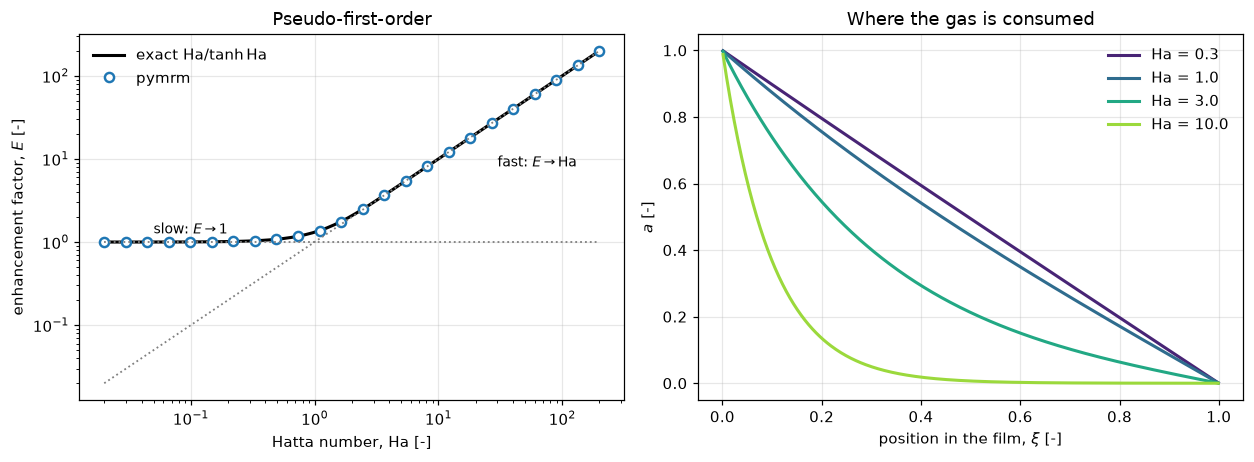

max relative error vs the exact solution: 6.337e-03


In [4]:
film1 = Film(n_x=400, n_c=1)
ha_grid = np.geomspace(0.02, 200.0, 70)
E_num = np.array([film1.solve_first_order(h)[1] for h in ha_grid])
E_exact = ha_grid / np.tanh(ha_grid)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].loglog(ha_grid, E_exact, "k-", lw=2, label=r"exact $\mathrm{Ha}/\tanh\mathrm{Ha}$")
axes[0].loglog(ha_grid[::3], E_num[::3], "o", color="tab:blue", ms=6,
               mfc="white", mew=1.6, label="pymrm")
axes[0].loglog(ha_grid, np.ones_like(ha_grid), ":", color="0.5", lw=1.2)
axes[0].loglog(ha_grid, ha_grid, ":", color="0.5", lw=1.2)
axes[0].text(0.05, 1.25, "slow: $E\\to1$", fontsize=9)
axes[0].text(30, 8, "fast: $E\\to\\mathrm{Ha}$", fontsize=9)
axes[0].set_xlabel(r"Hatta number, $\mathrm{Ha}$ [-]")
axes[0].set_ylabel("enhancement factor, $E$ [-]")
axes[0].set_title("Pseudo-first-order")
axes[0].legend(frameon=False)

for h, c in zip([0.3, 1.0, 3.0, 10.0], plt.cm.viridis(np.linspace(0.1, 0.85, 4))):
    axes[1].plot(film1.x_c, film1.solve_first_order(h)[0], color=c, lw=2,
                 label=rf"$\mathrm{{Ha}}$ = {h}")
axes[1].set_xlabel(r"position in the film, $\xi$ [-]")
axes[1].set_ylabel("$a$ [-]")
axes[1].set_title("Where the gas is consumed")
axes[1].legend(frameon=False)
fig.tight_layout(); plt.show()

err1 = np.max(np.abs(E_num - E_exact) / E_exact)
print(f"max relative error vs the exact solution: {err1:.3e}")

### Second order — and what the approximations cost

Now the co-reactant is depleted inside the film. $E$ can no longer exceed the
instantaneous ceiling $E_i$, and neither published formula is exact.

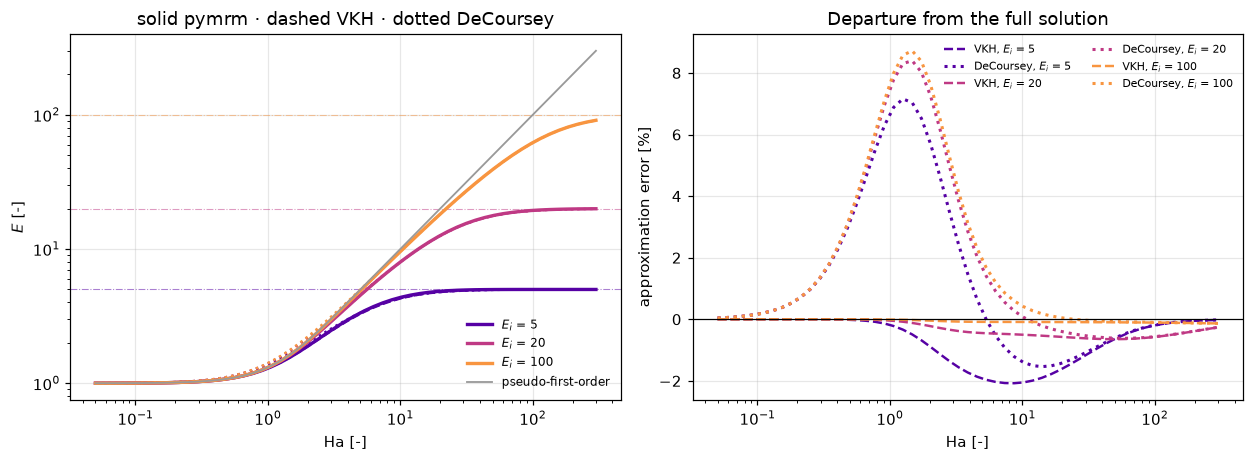

E_i =     5:  VKH max   2.1% (at Ha=  8.67)   DeCoursey max   7.2% (at Ha=  1.25)
E_i =    20:  VKH max   0.6% (at Ha= 50.99)   DeCoursey max   8.4% (at Ha=  1.47)
E_i =   100:  VKH max   0.1% (at Ha=300.00)   DeCoursey max   8.7% (at Ha=  1.47)


In [5]:
def vkh(ha, e_i):
    """Van Krevelen-Hoftijzer, solved for E by bisection."""
    def f(E):
        s = np.sqrt(max((e_i - E) / (e_i - 1.0), 0.0))
        return E - (ha * s / np.tanh(ha * s) if ha * s > 1e-12 else 1.0)
    return brentq(f, 1.0, e_i - 1e-12, xtol=1e-12)


def decoursey(ha, e_i):
    """DeCoursey's explicit approximation."""
    q = e_i - 1.0
    return -ha**2 / (2 * q) + np.sqrt(ha**4 / (4 * q**2) + e_i * ha**2 / q + 1.0)


film2 = Film(n_x=400, n_c=2)
E_I = [5.0, 20.0, 100.0]
ha2 = np.geomspace(0.05, 300.0, 55)
res = {}
for e_i in E_I:
    u_warm, rows = None, []
    for h in ha2:
        u_warm, E, ok = film2.solve_second_order(h, e_i, u_init=u_warm)
        rows.append((E if ok else np.nan, vkh(h, e_i), decoursey(h, e_i)))
    res[e_i] = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
cols = plt.cm.plasma(np.linspace(0.15, 0.75, len(E_I)))
for e_i, c in zip(E_I, cols):
    r = res[e_i]
    axes[0].loglog(ha2, r[:, 0], color=c, lw=2.2, label=rf"$E_i$ = {e_i:.0f}")
    axes[0].loglog(ha2, r[:, 1], "--", color=c, lw=1.4)
    axes[0].loglog(ha2, r[:, 2], ":", color=c, lw=1.6)
    axes[0].axhline(e_i, color=c, lw=0.7, ls="-.", alpha=0.5)
    axes[1].semilogx(ha2, 100 * (r[:, 1] - r[:, 0]) / r[:, 0], "--", color=c, lw=1.6,
                     label=rf"VKH, $E_i$ = {e_i:.0f}")
    axes[1].semilogx(ha2, 100 * (r[:, 2] - r[:, 0]) / r[:, 0], ":", color=c, lw=2,
                     label=rf"DeCoursey, $E_i$ = {e_i:.0f}")

axes[0].loglog(ha2, ha2 / np.tanh(ha2), color="0.6", lw=1.2,
               label="pseudo-first-order")
axes[0].set_xlabel(r"$\mathrm{Ha}$ [-]"); axes[0].set_ylabel("$E$ [-]")
axes[0].set_title("solid pymrm · dashed VKH · dotted DeCoursey")
axes[0].legend(frameon=False, fontsize=8)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel(r"$\mathrm{Ha}$ [-]")
axes[1].set_ylabel("approximation error [%]")
axes[1].set_title("Departure from the full solution")
axes[1].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

for e_i in E_I:
    r = res[e_i]
    v = 100 * np.abs(r[:, 1] - r[:, 0]) / r[:, 0]
    d = 100 * np.abs(r[:, 2] - r[:, 0]) / r[:, 0]
    print(f"E_i = {e_i:5.0f}:  VKH max {v.max():5.1f}% (at Ha={ha2[v.argmax()]:6.2f})"
          f"   DeCoursey max {d.max():5.1f}% (at Ha={ha2[d.argmax()]:6.2f})")

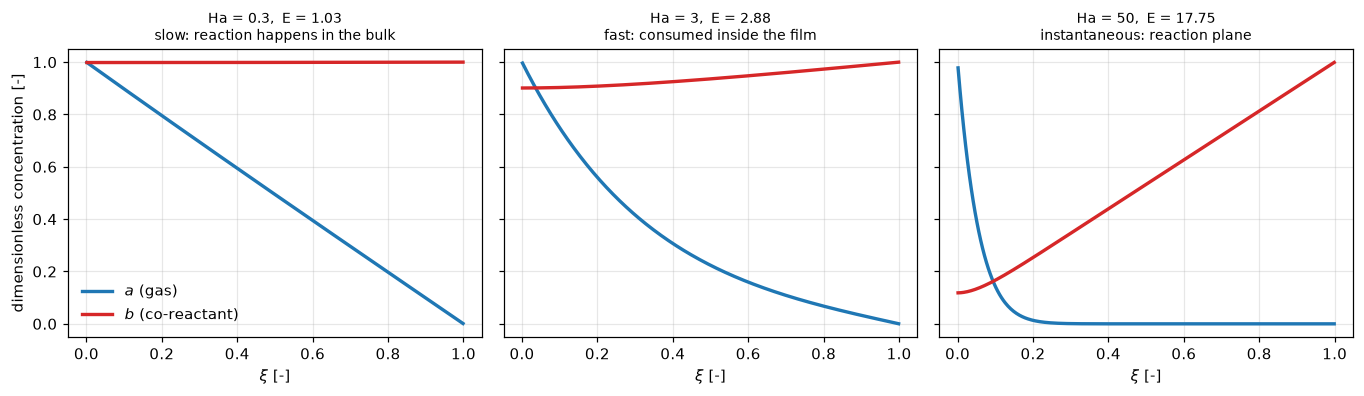

In [6]:
# The concentration profiles behind the three regimes.
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7), sharey=True)
for ax, h, tag in zip(axes, [0.3, 3.0, 50.0],
                      ["slow: reaction happens in the bulk",
                       "fast: consumed inside the film",
                       "instantaneous: reaction plane"]):
    u, E, _ = film2.solve_second_order(h, 20.0)
    ax.plot(film2.x_c, u[:, 0], color="tab:blue", lw=2.2, label="$a$ (gas)")
    ax.plot(film2.x_c, u[:, 1], color="tab:red", lw=2.2, label="$b$ (co-reactant)")
    ax.set_title(f"Ha = {h:g},  E = {E:.2f}\n{tag}", fontsize=9)
    ax.set_xlabel(r"$\xi$ [-]")
axes[0].set_ylabel("dimensionless concentration [-]")
axes[0].legend(frameon=False)
fig.tight_layout(); plt.show()

## Validation

Four checks; none uses fitted data.

In [7]:
# 1. First order against the exact closed form.
print(f"1. max rel. error vs Ha/tanh(Ha)          : {err1:.3e}")

# 2. Grid convergence.
errs = []
for n in (100, 200, 400, 800):
    f = Film(n_x=n, n_c=1)
    errs.append(abs(f.solve_first_order(5.0)[1] - 5.0 / np.tanh(5.0))
                / (5.0 / np.tanh(5.0)))
order = np.log2(errs[-2] / errs[-1])
print(f"2. observed order of convergence          : {order:.2f}   (expected 2)")

# 3. Limiting behaviour of the second-order solution:
#    E -> 1 as Ha -> 0, and E -> E_i as Ha -> infinity.
lo = res[20.0][0, 0]
hi = res[20.0][-1, 0]
print(f"3. E at Ha={ha2[0]:.2f} (expect 1)            : {lo:.4f}")
print(f"   E at Ha={ha2[-1]:.0f} (expect E_i = 20)      : {hi:.4f}")

# 4. Second-order must reduce to pseudo-first-order when the co-reactant
#    is in large excess.
film_x = Film(n_x=400, n_c=2)
dev = []
for h in (0.5, 2.0, 10.0):
    _, E2, _ = film_x.solve_second_order(h, 1.0e6)
    dev.append(abs(E2 - h / np.tanh(h)) / (h / np.tanh(h)))
print(f"4. E_i -> inf reduces to first order, max dev: {max(dev):.3e}")

report_agreement("F3.1", {
    "first_order_max_rel_error": float(err1),
    "convergence_order": float(order),
    "limit_E_small_Ha": float(lo),
    "limit_E_large_Ha": float(hi),
    "excess_reduces_to_first_order": float(max(dev)),
    "vkh_max_error_pct": float(max(
        np.max(100 * np.abs(res[e][:, 1] - res[e][:, 0]) / res[e][:, 0])
        for e in E_I)),
    "decoursey_max_error_pct": float(max(
        np.max(100 * np.abs(res[e][:, 2] - res[e][:, 0]) / res[e][:, 0])
        for e in E_I)),
})

1. max rel. error vs Ha/tanh(Ha)          : 6.337e-03


2. observed order of convergence          : 3.07   (expected 2)
3. E at Ha=0.05 (expect 1)            : 1.0008
   E at Ha=300 (expect E_i = 20)      : 19.9683
4. E_i -> inf reduces to first order, max dev: 5.384e-06
Agreement metrics for F3.1:
  first_order_max_rel_error     = 0.0063367
  convergence_order             = 3.0719
  limit_E_small_Ha              = 1.0008
  limit_E_large_Ha              = 19.968
  excess_reduces_to_first_order = 5.384e-06
  vkh_max_error_pct             = 2.0769
  decoursey_max_error_pct       = 8.7204


{'page': 'F3.1',
 'metrics': {'first_order_max_rel_error': 0.006336733444486526,
  'convergence_order': 3.0719034053588943,
  'limit_E_small_Ha': 1.0008331631554483,
  'limit_E_large_Ha': 19.96831594054015,
  'excess_reduces_to_first_order': 5.384037445220569e-06,
  'vkh_max_error_pct': 2.076893245879678,
  'decoursey_max_error_pct': 8.72038368927803}}

## What pymrm adds

**For the pseudo-first-order case, nothing** — and as on `B1.1`, that is the
point. The closed form is exact; reproducing it to $10^{-4}$ with second-order
convergence is what licenses the second-order result, where no closed form
exists.

**For the second-order case, the error bar on the standard formulas.** Van
Krevelen–Hoftijzer and DeCoursey are used constantly in absorber design and
almost always without a stated accuracy. Solving the film equations directly
puts a number on both, across the whole $(\mathrm{Ha}, E_i)$ plane, and shows
*where* they degrade — in the transition between the fast and instantaneous
regimes, which is precisely the operating region of a real amine absorber.

The full solve is not expensive: a few hundred cells and a Newton iteration.
There is no longer much reason to reach for the approximation when the equation
itself is this cheap.

## Reuse

| Change | Where |
|---|---|
| Reversible reaction / equilibrium | extend `rate` and add the product as a third component |
| Surface renewal instead of a film | replace the steady BVP with a transient penetration solve (`S4`) |
| Non-depleted bulk, $a(1) = a_b > 0$ | change `d` in the right-hand boundary dictionary |
| Gas-side resistance | make the interface a Robin condition instead of Dirichlet |
| Couple to a column | this is the local closure inside `F2.1`/`F3.5` |

**Related pages:** `F3.2` Van Krevelen–Hoftijzer · `F3.3` DeCoursey ·
`F3.5` CO₂–amine absorption · `B1.1` Thiele (the same `S3` equation with the
boundary conditions swapped) · `A4.9` Duncan–Toor.

## References

Hatta, S. (1932). *On the absorption velocity of gases by liquids.* Technological
Reports of Tôhoku University **10**, 119–128.

Van Krevelen, D. W. and Hoftijzer, P. J. (1948). *Kinetics of gas-liquid
reactions. Part I. General theory.* Recueil des Travaux Chimiques des Pays-Bas
**67**(7), 563–586. [doi:10.1002/recl.19480670708](https://doi.org/10.1002/recl.19480670708)

DeCoursey, W. J. (1974). *Absorption with chemical reaction: development of a new
relation for the Danckwerts model.* Chemical Engineering Science **29**(9),
1867–1872. [doi:10.1016/0009-2509(74)85003-7](https://doi.org/10.1016/0009-2509(74)85003-7)

Danckwerts, P. V. (1970). *Gas-Liquid Reactions.* McGraw-Hill.